In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,accuracy_score

In [73]:
df=pd.read_csv('../data/cleaned_student_data.csv')
df.head()

,sex,age,address,famsize,Parrent_status,Mother_edu,Father_edu,traveltime,weekly_studytime,failures,...,Mother_job_health,Mother_job_other,Mother_job_services,Mother_job_teacher,Father_job_health,Father_job_other,Father_job_teacher,reason_to_chose_school_other,reason_to_chose_school_reputation,guardian_other
0,0,18,1,0,0,4,4,2,2,0,...,0,0,0,0,0,0,1,0,0,0
1,0,17,1,0,1,1,1,1,2,0,...,0,0,0,0,0,1,0,0,0,0
2,0,15,1,1,1,1,1,1,2,3,...,0,0,0,0,0,1,0,1,0,0
3,0,15,1,0,1,4,2,1,3,0,...,1,0,0,0,0,0,0,0,0,0
4,0,16,1,0,1,3,3,1,2,0,...,0,1,0,0,0,1,0,0,0,0


In [74]:
df.columns

Index(['sex', 'age', 'address', 'famsize', 'Parrent_status', 'Mother_edu',
       'Father_edu', 'traveltime', 'weekly_studytime', 'failures',
       'extra_edu_supp', 'extra_paid_class', 'nursery',
       'Interested_in_higher_edu', 'internet_access', 'romantic_relationship',
       'Family_quality_reln', 'goout_with_friends', 'workday_alcohol_consum',
       'weekend_alcohol_consum', 'health_status', 'absences', 'G1', 'G2', 'G3',
       'grade_trend', 'high_alcohol', 'Mother_job_health', 'Mother_job_other',
       'Mother_job_services', 'Mother_job_teacher', 'Father_job_health',
       'Father_job_other', 'Father_job_teacher',
       'reason_to_chose_school_other', 'reason_to_chose_school_reputation',
       'guardian_other'],
      dtype='object')

In [75]:
df.shape

(395, 37)

**Train test Split**

In [76]:
from sklearn.model_selection import train_test_split
# Separate independent features X and target y
X = df.drop(columns=['G3'])
y = df['G3']


In [77]:
X.shape

(395, 36)

In [78]:
y.shape

(395,)

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [80]:
print(f'no. of input training samples: {X_train.shape[0]}')
print(f'no. of input training features:{X_train.shape[1]}')
print(f'no. of outtup training samples:{y_train.shape[0]}')


no. of input training samples: 316
no. of input training features:36
no. of outtup training samples:316


**Model Building**

Linear Regression

In [81]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('Linear Regression Results:')
print(f'  MAE: {mean_absolute_error(y_test, y_pred_lr):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f}')
print(f'  R2 Score: {r2_score(y_test, y_pred_lr):.4f}')

Linear Regression Results:
  MAE: 1.5919
  RMSE: 2.3153
  R2 Score: 0.7386


Decision Tree Regressor

In [82]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print('Decision Tree Results:')
print(f'  MAE: {mean_absolute_error(y_test, y_pred_dt):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_dt)):.4f}')
print(f'  R2 Score: {r2_score(y_test, y_pred_dt):.4f}')


Decision Tree Results:
  MAE: 1.2662
  RMSE: 2.2700
  R2 Score: 0.7487


Random Forest Regressor

In [83]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Random Forest Results:')
print(f'  MAE: {mean_absolute_error(y_test, y_pred_rf):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}')
print(f'  R2 Score: {r2_score(y_test, y_pred_rf):.4f}')

Random Forest Results:
  MAE: 1.1071
  RMSE: 1.8505
  R2 Score: 0.8330


Gradient Boosting Regressor

In [84]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print('Gradient Boosting Results:')
print(f'  MAE: {mean_absolute_error(y_test, y_pred_gb):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_gb)):.4f}')
print(f'  R2 Score: {r2_score(y_test, y_pred_gb):.4f}')


Gradient Boosting Results:
  MAE: 1.1072
  RMSE: 1.9024
  R2 Score: 0.8235


Model comparisions

In [85]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'MAE': [mean_absolute_error(y_test, y_pred_lr), mean_absolute_error(y_test, y_pred_dt), 
            mean_absolute_error(y_test, y_pred_rf), mean_absolute_error(y_test, y_pred_gb)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred_lr)), np.sqrt(mean_squared_error(y_test, y_pred_dt)), 
             np.sqrt(mean_squared_error(y_test, y_pred_rf)), np.sqrt(mean_squared_error(y_test, y_pred_gb))],
    'R2 Score': [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_dt), 
                 r2_score(y_test, y_pred_rf), r2_score(y_test, y_pred_gb)]
})

print('Model Performance Comparison:')
results.sort_values(by='R2 Score', ascending=False)

Model Performance Comparison:


,Model,MAE,RMSE,R2 Score
2,Random Forest,1.107090,1.850495,0.833001
3,Gradient Boosting,1.107223,1.902441,0.823493
1,Decision Tree,1.266200,2.270023,0.748696
0,Linear Regression,1.591921,2.315252,0.738582


In [87]:
models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_gb)
]

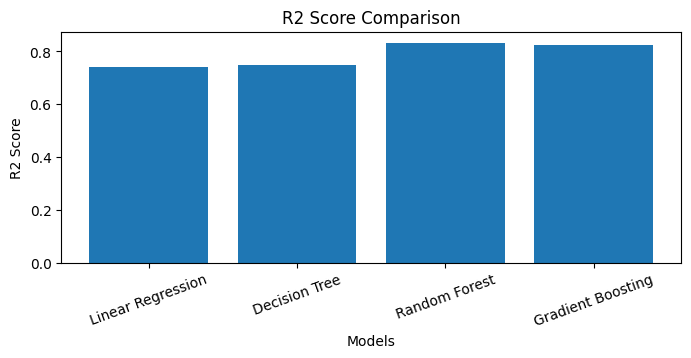

In [92]:
# Plot
plt.figure(figsize=(8, 3))
plt.bar(models, r2_scores)

plt.xlabel('Models')
plt.ylabel('R2 Score')
plt.title('R2 Score Comparison')

plt.xticks(rotation=20)
plt.show()

***conclusion: best model is Random Forest Classifier***

**Hyperparameter Tunning** use Grid search CV

Tune Linear Model (Ridge Regression)
Tuning the regularization parameter `alpha` to prevent overfitting.

In [94]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

param_grid_ridge = {'alpha': [0.1, 1.0, 10.0, 100.0]}
ridge_cv = GridSearchCV(Ridge(), param_grid_ridge, cv=5, scoring='r2')
ridge_cv.fit(X_train, y_train)

best_ridge = ridge_cv.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

print(f'Best Parameters (Ridge): {ridge_cv.best_params_}')
print(f'Tuned Ridge R² Accuracy: {r2_score(y_test, y_pred_ridge)*100:.2f}%')

Best Parameters (Ridge): {'alpha': 100.0}
Tuned Ridge R² Accuracy: 77.69%


Tune Decision Tree,
Tuning `max_depth` and `min_samples_split`.

In [95]:
param_grid_dt = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10]
}
dt_cv = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid_dt, cv=5, scoring='r2')
dt_cv.fit(X_train, y_train)

best_dt = dt_cv.best_estimator_
y_pred_dt_tuned = best_dt.predict(X_test)

print(f'Best Parameters (DT): {dt_cv.best_params_}')
print(f'Tuned DT R² Accuracy: {r2_score(y_test, y_pred_dt_tuned)*100:.2f}%')

Best Parameters (DT): {'max_depth': 3, 'min_samples_split': 2}
Tuned DT R² Accuracy: 77.06%


Tune Random Forest ,
Tuning `n_estimators` and `max_depth`.

In [96]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 7, 10, None],
    'min_samples_split': [2, 5]
}
rf_cv = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=5, scoring='r2')
rf_cv.fit(X_train, y_train)

best_rf = rf_cv.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

print(f'Best Parameters (RF): {rf_cv.best_params_}')
print(f'Tuned RF R² Accuracy: {r2_score(y_test, y_pred_rf_tuned)*100:.2f}%')

Best Parameters (RF): {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Tuned RF R² Accuracy: 83.18%


Tune Gradient Boosting,
Tuning `n_estimators`, `learning_rate`, and `max_depth

In [97]:
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}
gb_cv = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid_gb, cv=5, scoring='r2')
gb_cv.fit(X_train, y_train)

best_gb = gb_cv.best_estimator_
y_pred_gb_tuned = best_gb.predict(X_test)

print(f'Best Parameters (GB): {gb_cv.best_params_}')
print(f'Tuned GB R² Accuracy: {r2_score(y_test, y_pred_gb_tuned)*100:.2f}%')

Best Parameters (GB): {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Tuned GB R² Accuracy: 82.35%


In [100]:
final_results = pd.DataFrame({
    'Model': ['Ridge (Tuned)', 'Decision Tree (Tuned)', 'Random Forest (Tuned)', 'Gradient Boosting (Tuned)'],
    'MAE': [mean_absolute_error(y_test, y_pred_ridge), mean_absolute_error(y_test, y_pred_dt_tuned), 
            mean_absolute_error(y_test, y_pred_rf_tuned), mean_absolute_error(y_test, y_pred_gb_tuned)],
    'Accuracy (R2)': [r2_score(y_test, y_pred_ridge)*100, r2_score(y_test, y_pred_dt_tuned)*100, 
                       r2_score(y_test, y_pred_rf_tuned)*100, r2_score(y_test, y_pred_gb_tuned)*100],
    
})

print('Optimized Model Performance:')
final_results.sort_values(by='Accuracy (R2)', ascending=False)

Optimized Model Performance:


,Model,MAE,Accuracy (R2)
2,Random Forest (Tuned),1.108862,83.177418
3,Gradient Boosting (Tuned),1.107223,82.349313
0,Ridge (Tuned),1.419503,77.694210
1,Decision Tree (Tuned),1.309991,77.062583


Still the best model is RandomForestRegressor


**Model dump/Export**

In [107]:
import os
import pickle

In [108]:
# Save the Optimized Random Forest Model
with open('../models/student_rf_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

In [110]:
# Save Feature Names (required for the UI to know input order)
features = X.columns.tolist()
with open('../models/features.pkl', 'wb') as f:
    pickle.dump(features, f)